# Optativa III: Ciencia de Datos
## Actividad práctica — Probabilidad aplicada, teorema de Bayes e inferencia

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 2 · Sesión 2**

---

### Propósito

En esta actividad aplicarás la **probabilidad condicional**, el **teorema de Bayes**, el concepto de **variables aleatorias** y los **intervalos de confianza** en dos partes:

- **Parte A —** Construirás un **filtro de spam conceptual** con el teorema de Bayes, paso a paso, y experimentarás modificando sus parámetros.
- **Parte B —** Resolverás un **set de 6 problemas de probabilidad e inferencia** sobre un **dataset real** de un restaurante.

A lo largo del cuaderno responderás **20 preguntas** (marcadas con ✍️). No basta con ejecutar: en cada bloque deberás **modificar valores, volver a correr y explicar** lo que observas.

### Cómo trabajar en Google Colab

1. Abre este archivo en [Google Colab](https://colab.research.google.com) (Archivo → Subir cuaderno).
2. Ejecuta cada celda con **Shift + Enter**, en orden.
3. Responde en las celdas de texto ✍️ (doble clic para editar).
4. Al terminar: **Archivo → Guardar una copia en Drive** y entrega el enlace en Classroom.


---
## Paso 0 — Preparación del entorno


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print("Entorno listo. Librerias importadas correctamente.")

Entorno listo. Librerias importadas correctamente.


> ✍️ **Pregunta 1 — Respuesta:**

La **probabilidad simple** P(A) mide qué tan probable es que ocurra un evento A sin considerar otra condición. Por ejemplo, la probabilidad de que un día elegido al azar sea sábado. La **probabilidad condicional** P(A|B) mide qué tan probable es A cuando sabemos que B ya ocurrió. Por ejemplo, la probabilidad de que una persona lleve paraguas **dado que** está lloviendo.


---
# PARTE A — Filtro de spam con el teorema de Bayes

## Paso 1 — El problema

Queremos clasificar un correo como **spam** o **legítimo (ham)** según las palabras que contiene. El teorema de Bayes nos permite calcular la probabilidad de que un correo sea spam **dado que** contiene cierta palabra:

$$P(spam \mid palabra) = \frac{P(palabra \mid spam) \cdot P(spam)}{P(palabra)}$$

donde:
- **P(spam)** es la probabilidad previa (qué proporción de correos es spam en general).
- **P(palabra | spam)** es la verosimilitud (qué tan frecuente es la palabra en el spam).
- **P(palabra)** es la probabilidad total de ver la palabra.


In [2]:
# Datos base del problema (probabilidades conocidas por experiencia)
P_spam = 0.40          # 40% de los correos que llegan son spam
P_ham  = 1 - P_spam    # el resto son legitimos

# Verosimilitudes: que tan seguido aparece la palabra "gratis" en cada tipo
P_gratis_dado_spam = 0.80   # el 80% de los spam contienen "gratis"
P_gratis_dado_ham  = 0.10   # solo el 10% de los correos legitimos la usan

print(f"P(spam)              = {P_spam}")
print(f"P(ham)               = {P_ham}")
print(f"P(gratis | spam)     = {P_gratis_dado_spam}")
print(f"P(gratis | ham)      = {P_gratis_dado_ham}")

P(spam)              = 0.4
P(ham)               = 0.6
P(gratis | spam)     = 0.8
P(gratis | ham)      = 0.1


> ✍️ **Pregunta 2 — Respuesta:**

La probabilidad previa es **P(spam) = 0.40**, es decir, 40%. Es la proporción de correos que el modelo considera spam antes de observar una palabra. En un sistema real podría estimarse a partir del historial de correos recibidos y etiquetados como spam o legítimos.


## Paso 2 — Aplicando el teorema de Bayes

Calculamos la probabilidad total de la palabra con el **teorema de la probabilidad total** y luego aplicamos Bayes.


In [3]:
# Teorema de la probabilidad total: P(gratis)
P_gratis = P_gratis_dado_spam * P_spam + P_gratis_dado_ham * P_ham

# Teorema de Bayes: P(spam | gratis)
P_spam_dado_gratis = (P_gratis_dado_spam * P_spam) / P_gratis

print(f"P(gratis)               = {P_gratis:.4f}")
print(f"P(spam | 'gratis')      = {P_spam_dado_gratis:.4f}  ->  {P_spam_dado_gratis*100:.1f}%")
print()
if P_spam_dado_gratis > 0.5:
    print("Decision: clasificar como SPAM")
else:
    print("Decision: clasificar como LEGITIMO")

P(gratis)               = 0.3800
P(spam | 'gratis')      = 0.8421  ->  84.2%

Decision: clasificar como SPAM


> ✍️ **Pregunta 3 — Respuesta:**

La probabilidad es **P(spam | "gratis") = 0.8421**, aproximadamente **84.2%**. Como supera el umbral de 50% usado por este ejercicio, el sistema lo clasifica como **SPAM**.

> ✍️ **Pregunta 4 — Respuesta:**

P(gratis | spam) = 0.80 significa que, entre los correos que ya sabemos que son spam, el 80% contiene la palabra "gratis". En cambio, P(spam | gratis) = 0.8421 significa que, entre los correos que contienen "gratis", aproximadamente el 84.2% son spam. Son preguntas diferentes porque cambia el evento que estamos buscando y la información que conocemos. Bayes permite relacionarlas usando también las probabilidades previas.


## Paso 3 — Función reutilizable del clasificador

Convertimos el cálculo en una función para poder probar distintas palabras y parámetros con facilidad.


In [4]:
def clasificar_bayes(P_spam, P_palabra_dado_spam, P_palabra_dado_ham):
    """Devuelve P(spam | palabra) usando el teorema de Bayes."""
    P_ham = 1 - P_spam
    P_palabra = P_palabra_dado_spam * P_spam + P_palabra_dado_ham * P_ham
    return (P_palabra_dado_spam * P_spam) / P_palabra

# Probamos con varias palabras (cada una con su verosimilitud)
palabras = {
    "gratis":   (0.80, 0.10),
    "reunion":  (0.05, 0.40),
    "oferta":   (0.70, 0.15),
    "proyecto": (0.03, 0.50),
    "premio":   (0.85, 0.05),
}

print(f"{'Palabra':<12}{'P(spam|palabra)':>18}")
print("-"*30)
for palabra, (p_spam, p_ham) in palabras.items():
    resultado = clasificar_bayes(0.40, p_spam, p_ham)
    etiqueta = "SPAM" if resultado > 0.5 else "legitimo"
    print(f"{palabra:<12}{resultado*100:>15.1f}%   {etiqueta}")

Palabra        P(spam|palabra)
------------------------------
gratis                 84.2%   SPAM
reunion                 7.7%   legitimo
oferta                 75.7%   SPAM
proyecto                3.8%   legitimo
premio                 91.9%   SPAM


> ✍️ **Pregunta 5 — Respuesta:**

Según la tabla, **"gratis" (84.2%), "oferta" (75.7%) y "premio" (91.9%)** se clasifican como spam. **"reunion" (7.7%) y "proyecto" (3.8%)** se clasifican como legítimos. Sí tiene sentido intuitivamente: las primeras palabras aparecen con mayor frecuencia en spam según las verosimilitudes dadas, mientras que "reunion" y "proyecto" son más características de correos legítimos.

> ✍️ **Pregunta 6 — Respuesta:**

"reunion" tiene **P(reunion | spam) = 0.05** y **P(reunion | ham) = 0.40**. La palabra es mucho más probable en correos legítimos que en spam. Por eso la evidencia favorece a ham y la probabilidad posterior de spam resulta baja: **7.7%**.


### 🔧 Reto de modificación 1

Agrega **dos palabras nuevas** al diccionario `palabras` (por ejemplo "descuento" y "tarea") con las verosimilitudes que consideres realistas, y vuelve a ejecutar.


In [5]:
def clasificar_bayes(P_spam, P_palabra_dado_spam, P_palabra_dado_ham):
    """Devuelve P(spam | palabra) usando el teorema de Bayes."""
    P_ham = 1 - P_spam
    P_palabra = P_palabra_dado_spam * P_spam + P_palabra_dado_ham * P_ham
    return (P_palabra_dado_spam * P_spam) / P_palabra

palabras_ampliado = {
    "gratis":   (0.80, 0.10),
    "reunion":  (0.05, 0.40),
    "oferta":   (0.70, 0.15),
    "proyecto": (0.03, 0.50),
    "premio":   (0.85, 0.05),
    "descuento": (0.75, 0.08),
    "tarea":     (0.02, 0.60),
}

print(f"{'Palabra':<12}{'P(spam|palabra)':>18}")
print("-"*30)
for palabra, (p_spam, p_ham) in palabras_ampliado.items():
    r = clasificar_bayes(0.40, p_spam, p_ham)
    etiqueta = "SPAM" if r > 0.5 else "legitimo"
    print(f"{palabra:<12}{r*100:>15.1f}%   {etiqueta}")

Palabra        P(spam|palabra)
------------------------------
gratis                 84.2%   SPAM
reunion                 7.7%   legitimo
oferta                 75.7%   SPAM
proyecto                3.8%   legitimo
premio                 91.9%   SPAM
descuento              86.2%   SPAM
tarea                   2.2%   legitimo


> ✍️ **Pregunta 7 — Respuesta:**

Elegí **"descuento" = (0.75, 0.08)** porque considero razonable que aparezca con frecuencia en spam y mucho menos en correos legítimos. Para **"tarea" = (0.02, 0.60)** supuse lo contrario: es mucho más común en correos legítimos que en spam. El clasificador coincidió con lo esperado: "descuento" dio **86.2% de spam**, mientras que "tarea" dio **2.2%**, por lo que se clasificaron como spam y legítimo, respectivamente.


## Paso 4 — El efecto de la probabilidad previa (prior)

La probabilidad previa P(spam) tiene un efecto enorme en el resultado. Veamos qué pasa si cambia la proporción de spam que recibe el servidor.


P(spam)=0.05  ->  P(spam | 'gratis') = 29.6%
P(spam)=0.20  ->  P(spam | 'gratis') = 66.7%
P(spam)=0.40  ->  P(spam | 'gratis') = 84.2%
P(spam)=0.60  ->  P(spam | 'gratis') = 92.3%
P(spam)=0.90  ->  P(spam | 'gratis') = 98.6%


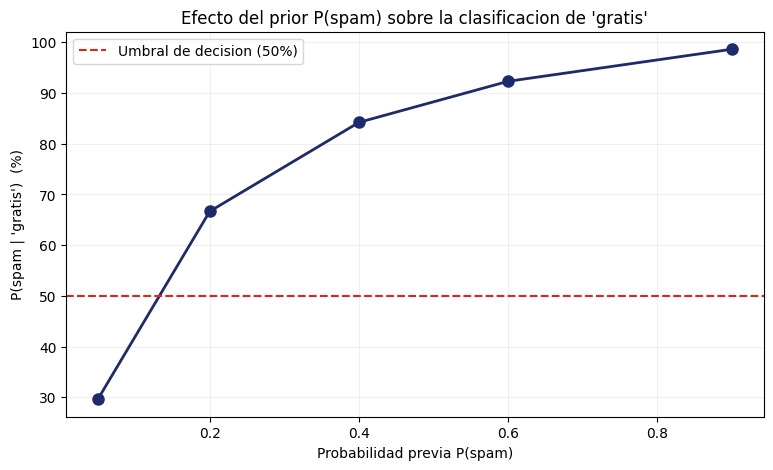

In [6]:
# Mantenemos la palabra "gratis" (0.80 en spam, 0.10 en ham)
# y variamos el prior P(spam)
priors = [0.05, 0.20, 0.40, 0.60, 0.90]

resultados = []
for prior in priors:
    r = clasificar_bayes(prior, 0.80, 0.10)
    resultados.append(r)
    print(f"P(spam)={prior:.2f}  ->  P(spam | 'gratis') = {r*100:.1f}%")

plt.figure(figsize=(9,5))
plt.plot(priors, [r*100 for r in resultados], "o-", color="#1e2a6b", linewidth=2, markersize=8)
plt.axhline(50, color="#e2231a", linestyle="--", label="Umbral de decision (50%)")
plt.title("Efecto del prior P(spam) sobre la clasificacion de 'gratis'")
plt.xlabel("Probabilidad previa P(spam)")
plt.ylabel("P(spam | 'gratis')  (%)")
plt.legend(); plt.grid(alpha=0.2); plt.show()

> ✍️ **Pregunta 8 — Respuesta:**

No. Con P(spam) = 0.05, aunque el correo contiene "gratis", la probabilidad posterior es solo **29.6%**, por debajo del 50% del clasificador. Esto muestra que la evidencia de una palabra no puede analizarse aislada: el **prior** representa el contexto inicial y puede cambiar mucho la decisión final.

> ✍️ **Pregunta 9 — Respuesta:**

Con un prior de 5%, P(spam | "gratis") es aproximadamente **29.6%**; con un prior de 60%, sube a aproximadamente **92.3%**. Por eso el mismo correo puede clasificarse como legítimo en el servidor corporativo y como spam en la cuenta personal. La gráfica muestra justamente que, al aumentar el prior, aumenta la probabilidad posterior de spam.


## Paso 5 — Combinando varias palabras (Naive Bayes)

Un filtro real no mira una sola palabra. El clasificador **Naive Bayes** combina la evidencia de varias palabras asumiendo (de forma "ingenua") que son independientes. Aquí lo hacemos con dos palabras.


In [7]:
def naive_bayes_dos_palabras(P_spam, verosim1, verosim2):
    """Clasifica usando dos palabras simultaneamente.
       verosim = (P(palabra|spam), P(palabra|ham))"""
    P_ham = 1 - P_spam
    # Verosimilitud conjunta asumiendo independencia
    L_spam = verosim1[0] * verosim2[0] * P_spam
    L_ham  = verosim1[1] * verosim2[1] * P_ham
    return L_spam / (L_spam + L_ham)

# Un correo que contiene "gratis" Y "premio"
p = naive_bayes_dos_palabras(0.40, (0.80, 0.10), (0.85, 0.05))
print(f"Correo con 'gratis' Y 'premio':  P(spam) = {p*100:.2f}%")

# Un correo con "gratis" pero tambien "proyecto"
p2 = naive_bayes_dos_palabras(0.40, (0.80, 0.10), (0.03, 0.50))
print(f"Correo con 'gratis' Y 'proyecto': P(spam) = {p2*100:.2f}%")

Correo con 'gratis' Y 'premio':  P(spam) = 98.91%
Correo con 'gratis' Y 'proyecto': P(spam) = 24.24%


> ✍️ **Pregunta 10 — Respuesta:**

Al añadir **"premio"**, la probabilidad sube hasta **98.91%**, porque ambas palabras son mucho más probables en spam que en ham. Al añadir **"proyecto"**, baja hasta **24.24%**, porque "proyecto" favorece fuertemente a los correos legítimos. En Naive Bayes la evidencia de cada palabra se combina multiplicando sus verosimilitudes; por eso una segunda palabra puede reforzar o contradecir la evidencia de la primera.

> ✍️ **Pregunta 11 — Respuesta:**

Se llama "ingenuo" porque supone que las palabras son **condicionalmente independientes** una de otra dado que el correo sea spam o ham. En lenguaje real esta suposición rara vez se cumple: por ejemplo, palabras como "tarjeta" y "crédito" suelen aparecer juntas. Aun así, el modelo puede funcionar bien porque simplifica mucho el cálculo.


---
# PARTE B — Problemas de probabilidad e inferencia sobre un dataset real

## Paso 6 — Cargamos el dataset

Usaremos el dataset **`tips`**, con **244 registros reales** de propinas de un restaurante. Incluye la cuenta total, la propina, el sexo del cliente, si es fumador, el día y el momento (comida/cena) y el tamaño del grupo. Se carga directo desde `seaborn`, sin descargas.


In [8]:
import seaborn as sns

try:
    # Carga original del ejercicio. Requiere conexión a Internet la primera vez.
    df = sns.load_dataset("tips")
except Exception:
    # Fallback local incluido en Plotly para poder ejecutar el notebook sin Internet.
    import plotly.express as px
    df = px.data.tips()

print("Dimensiones:", df.shape)
print()
print(df.head())
print()
print("Resumen de variables categoricas:")
for col in ["sex", "smoker", "day", "time"]:
    print(f"  {col}: {df[col].unique().tolist()}")


Dimensiones: (244, 7)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Resumen de variables categoricas:
  sex: ['Female', 'Male']
  smoker: ['No', 'Yes']
  day: ['Sun', 'Sat', 'Thur', 'Fri']
  time: ['Dinner', 'Lunch']


> ✍️ **Pregunta 12 — Respuesta:**

El dataset **tips** tiene **244 registros y 7 variables**. Cada fila representa una visita o cuenta registrada en un restaurante y contiene información sobre la cuenta, la propina, quién pagó, si había fumadores, el día, el momento de la comida y el tamaño del grupo. Las variables **categóricas** son `sex`, `smoker`, `day` y `time`. Las variables **numéricas** son `total_bill`, `tip` y `size`.


## Problema 1 — Probabilidad simple

Calculamos probabilidades básicas como frecuencias relativas.


In [9]:
total = len(df)

# P(cliente sea fumador)
p_fumador = (df["smoker"] == "Yes").sum() / total
# P(la visita sea en la cena)
p_cena = (df["time"] == "Dinner").sum() / total

print(f"P(fumador)      = {p_fumador:.4f}  ({p_fumador*100:.1f}%)")
print(f"P(cena)         = {p_cena:.4f}  ({p_cena*100:.1f}%)")

P(fumador)      = 0.3811  (38.1%)
P(cena)         = 0.7213  (72.1%)


> ✍️ **Pregunta 13 — Respuesta:**

```python
p_hombre = (df["sex"] == "Male").mean()
p_finde = df["day"].isin(["Sat", "Sun"]).mean()

print(f"P(hombre)   = {p_hombre:.4f} ({p_hombre*100:.1f}%)")
print(f"P(fin de semana) = {p_finde:.4f} ({p_finde*100:.1f}%)")
```

Los resultados son **P(hombre) = 0.6434 (64.3%)** y **P(fin de semana) = 0.6680 (66.8%)**.


In [10]:
# Probabilidad de que el cliente sea hombre
p_hombre = (df["sex"] == "Male").mean()

# Probabilidad de que la visita sea en fin de semana
p_finde = df["day"].isin(["Sat", "Sun"]).mean()

print(f"P(hombre)        = {p_hombre:.4f} ({p_hombre*100:.1f}%)")
print(f"P(fin de semana) = {p_finde:.4f} ({p_finde*100:.1f}%)")


P(hombre)        = 0.6434 (64.3%)
P(fin de semana) = 0.6680 (66.8%)


## Problema 2 — Probabilidad condicional

Ahora condicionamos: la probabilidad de un evento **dado que** otro ocurrió.


In [11]:
# P(fumador | es cena)  =  P(fumador Y cena) / P(cena)
cena = df[df["time"] == "Dinner"]
p_fumador_dado_cena = (cena["smoker"] == "Yes").sum() / len(cena)

print(f"P(fumador | cena) = {p_fumador_dado_cena:.4f}  ({p_fumador_dado_cena*100:.1f}%)")

# Comparamos con la probabilidad no condicionada
print(f"P(fumador)        = {(df['smoker']=='Yes').mean():.4f}  (para comparar)")

P(fumador | cena) = 0.3977  (39.8%)
P(fumador)        = 0.3811  (para comparar)


> ✍️ **Pregunta 14 — Respuesta:**

Sí, cambia ligeramente: **P(fumador) = 0.3811 (38.1%)** y **P(fumador | cena) = 0.3977 (39.8%)**. La diferencia es pequeña, por lo que en este dataset la condición "cena" no cambia mucho la probabilidad de ser fumador. Esto sugiere que ambas variables tienen una relación relativamente débil en estos datos, aunque no demuestra por sí sola independencia estadística.

> ✍️ **Pregunta 15 — Respuesta:**

```python
fumadores = df[df["smoker"] == "Yes"]
p_cena_dado_fumador = (fumadores["time"] == "Dinner").mean()
print(f"P(cena | fumador) = {p_cena_dado_fumador:.4f} ({p_cena_dado_fumador*100:.1f}%)")
```

El resultado es **0.7527 (75.3%)**. No es igual a P(fumador | cena) = 0.3977. El orden importa porque una probabilidad condiciona sobre un evento diferente: una pregunta parte de los fumadores y la otra parte de las cenas.


In [12]:
# P(cena | fumador)
fumadores = df[df["smoker"] == "Yes"]
p_cena_dado_fumador = (fumadores["time"] == "Dinner").mean()

print(f"P(cena | fumador) = {p_cena_dado_fumador:.4f} ({p_cena_dado_fumador*100:.1f}%)")


P(cena | fumador) = 0.7527 (75.3%)


## Problema 3 — Teorema de Bayes sobre el dataset

Aplicamos Bayes con datos reales para invertir una condicional.


In [13]:
# Queremos P(cena | grupo grande), definiendo "grupo grande" = size >= 4
# Bayes:  P(cena | grande) = P(grande | cena) * P(cena) / P(grande)

df["grande"] = df["size"] >= 4

P_cena     = (df["time"] == "Dinner").mean()
P_grande   = df["grande"].mean()
P_grande_dado_cena = df[df["time"]=="Dinner"]["grande"].mean()

P_cena_dado_grande = (P_grande_dado_cena * P_cena) / P_grande

print(f"P(cena)                = {P_cena:.4f}")
print(f"P(grupo grande)        = {P_grande:.4f}")
print(f"P(grande | cena)       = {P_grande_dado_cena:.4f}")
print(f"P(cena | grupo grande) = {P_cena_dado_grande:.4f}  <- via Bayes")

# Verificacion directa
verif = (df[df["grande"]]["time"] == "Dinner").mean()
print(f"Verificacion directa   = {verif:.4f}")

P(cena)                = 0.7213
P(grupo grande)        = 0.1885
P(grande | cena)       = 0.2102
P(cena | grupo grande) = 0.8043  <- via Bayes
Verificacion directa   = 0.8043


> ✍️ **Pregunta 16 — Respuesta:**

Sí, coinciden: **P(cena | grupo grande) ≈ 0.8043** tanto mediante Bayes como mediante el cálculo directo. Esto confirma que el teorema de Bayes permite reorganizar correctamente las probabilidades y obtener una probabilidad condicional a partir de otras probabilidades relacionadas.


## Problema 4 — Variables aleatorias: valor esperado y varianza

La propina (`tip`) es una **variable aleatoria continua**. Calculamos su valor esperado (media), varianza y desviación estándar.


E[propina]   (valor esperado) = $3.00
Var(propina)                  = 1.91
Desv. estandar                = $1.38


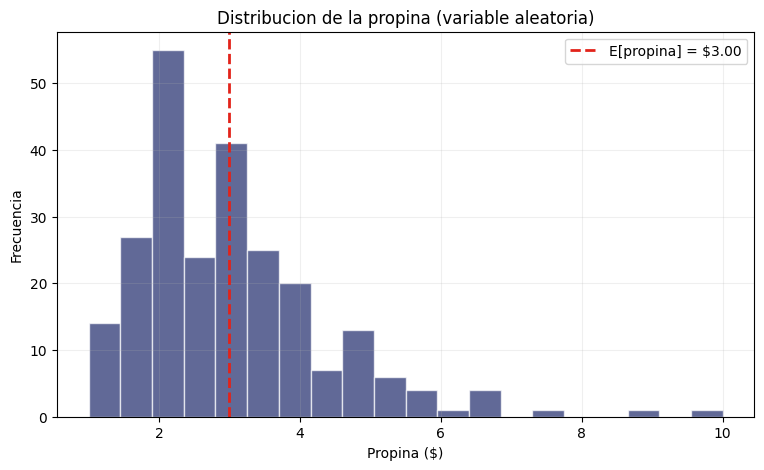

In [14]:
tip = df["tip"]

esperanza = tip.mean()      # E[X], valor esperado
varianza  = tip.var(ddof=1) # Var(X)
desv      = tip.std(ddof=1)

print(f"E[propina]   (valor esperado) = ${esperanza:.2f}")
print(f"Var(propina)                  = {varianza:.2f}")
print(f"Desv. estandar                = ${desv:.2f}")

plt.figure(figsize=(9,5))
plt.hist(tip, bins=20, color="#1e2a6b", alpha=0.7, edgecolor="white")
plt.axvline(esperanza, color="#e2231a", linestyle="--", linewidth=2,
            label=f"E[propina] = ${esperanza:.2f}")
plt.title("Distribucion de la propina (variable aleatoria)")
plt.xlabel("Propina ($)"); plt.ylabel("Frecuencia")
plt.legend(); plt.grid(alpha=0.2); plt.show()

> ✍️ **Pregunta 17 — Respuesta:**

El valor esperado de la propina es aproximadamente **$3.00 por mesa**. Esto significa que, a largo plazo, si se observaran muchas mesas bajo condiciones similares, la propina promedio tendería a acercarse a ese valor. Para 500 mesas, esperaríamos recaudar aproximadamente **$1,499.14** en propinas. La operación utilizada es **500 × E[propina] = 500 × 2.9983**.


## Problema 5 — Intervalo de confianza para la media

Estimamos un **intervalo de confianza del 95%** para la propina promedio. Este rango expresa la incertidumbre de estimar la media poblacional a partir de la muestra.


In [15]:
n         = len(tip)
media     = tip.mean()
error_est = tip.std(ddof=1) / np.sqrt(n)   # error estandar de la media

# Intervalo de confianza del 95% usando la distribucion t de Student
confianza = 0.95
ic = stats.t.interval(confianza, df=n-1, loc=media, scale=error_est)

print(f"Tamano de muestra (n)       = {n}")
print(f"Media muestral              = ${media:.3f}")
print(f"Error estandar              = ${error_est:.3f}")
print(f"IC del 95% para la media    = (${ic[0]:.3f}, ${ic[1]:.3f})")
print()
print(f"Interpretacion: con 95% de confianza, la propina promedio real")
print(f"esta entre ${ic[0]:.2f} y ${ic[1]:.2f}.")

Tamano de muestra (n)       = 244
Media muestral              = $2.998
Error estandar              = $0.089
IC del 95% para la media    = ($2.824, $3.173)

Interpretacion: con 95% de confianza, la propina promedio real
esta entre $2.82 y $3.17.


> ✍️ **Pregunta 18 — Respuesta:**

El IC del 95% obtenido es aproximadamente **($2.824, $3.173)**. La interpretación frecuentista correcta no es decir que existe un 95% de probabilidad de que la media poblacional esté dentro de este intervalo una vez calculado. La media poblacional es un parámetro fijo; lo que tiene una cobertura del 95% es el **procedimiento** de construcción del intervalo: si repitiéramos el muestreo muchas veces y construyéramos un intervalo de la misma manera, aproximadamente 95% de esos intervalos contendrían la media poblacional.

> ✍️ **Pregunta 19 — Respuesta:**

Al usar 99% de confianza, el intervalo es **más ancho**: aproximadamente **($2.768, $3.228)**, frente a **($2.824, $3.173)** al 95%. Mayor confianza exige cubrir una gama más amplia de valores posibles de la media, por lo que aumenta el margen de error y el intervalo se ensancha.


In [16]:
# Intervalo de confianza del 99%
ic_99 = stats.t.interval(0.99, df=n-1, loc=media, scale=error_est)
print(f"IC del 95% = (${ic[0]:.3f}, ${ic[1]:.3f})")
print(f"IC del 99% = (${ic_99[0]:.3f}, ${ic_99[1]:.3f})")


IC del 95% = ($2.824, $3.173)
IC del 99% = ($2.768, $3.228)


## Problema 6 — Inferencia: comparación entre grupos

¿Los fumadores dejan propinas distintas que los no fumadores? Comparamos las medias y sus intervalos de confianza.


Fumadores    : media=$3.01  IC95%=($2.72, $3.30)  n=93
No fumadores : media=$2.99  IC95%=($2.77, $3.21)  n=151


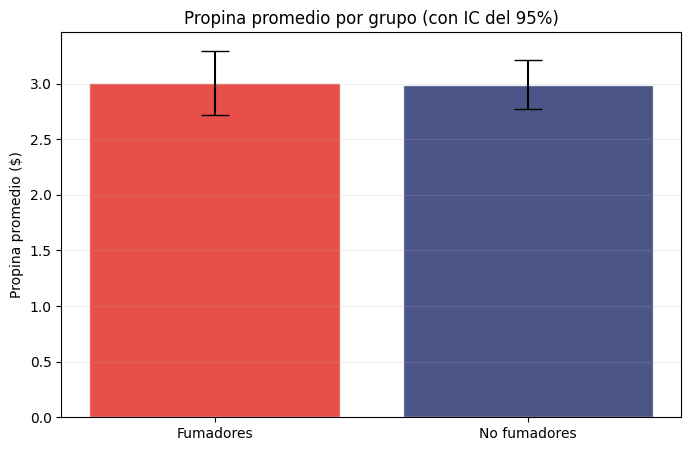

In [17]:
def ic_media(serie, confianza=0.95):
    n = len(serie)
    m = serie.mean()
    ee = serie.std(ddof=1) / np.sqrt(n)
    lo, hi = stats.t.interval(confianza, df=n-1, loc=m, scale=ee)
    return m, lo, hi

tip_fuma    = df[df["smoker"]=="Yes"]["tip"]
tip_no_fuma = df[df["smoker"]=="No"]["tip"]

m1, lo1, hi1 = ic_media(tip_fuma)
m2, lo2, hi2 = ic_media(tip_no_fuma)

print(f"Fumadores    : media=${m1:.2f}  IC95%=(${lo1:.2f}, ${hi1:.2f})  n={len(tip_fuma)}")
print(f"No fumadores : media=${m2:.2f}  IC95%=(${lo2:.2f}, ${hi2:.2f})  n={len(tip_no_fuma)}")

plt.figure(figsize=(8,5))
grupos = ["Fumadores", "No fumadores"]
medias = [m1, m2]
errores = [[m1-lo1, m2-lo2],[hi1-m1, hi2-m2]]
plt.bar(grupos, medias, yerr=errores, capsize=10,
        color=["#e2231a","#1e2a6b"], alpha=0.8, edgecolor="white")
plt.title("Propina promedio por grupo (con IC del 95%)")
plt.ylabel("Propina promedio ($)")
plt.grid(alpha=0.2, axis="y"); plt.show()

> ✍️ **Pregunta 20 — Respuesta:**

Los intervalos se **traslapan bastante**: fumadores tienen aproximadamente **IC95% = ($2.72, $3.30)** y no fumadores **IC95% = ($2.77, $3.21)**. Además, sus medias son muy parecidas: **$3.01** y **$2.99**, respectivamente. Por lo tanto, con esta comparación descriptiva no hay evidencia clara de que los fumadores y no fumadores dejen propinas distintas. Para afirmar una diferencia estadísticamente significativa sería conveniente realizar una prueba de hipótesis apropiada, no basarse únicamente en el traslape visual.


---
## Cierre — Reflexión y entrega

> **Reflexión final:** El concepto que considero más útil para mi futuro como ingeniero en computación es el **teorema de Bayes**, porque permite actualizar una probabilidad cuando aparece nueva evidencia. Esto tiene aplicaciones directas en sistemas inteligentes, por ejemplo en un sistema de detección de fraude: primero se puede estimar la probabilidad previa de que una transacción sea fraudulenta y después actualizarla usando características como el monto, la ubicación, la hora o el comportamiento histórico del usuario. De esta manera, el sistema puede combinar información previa con nueva evidencia para tomar decisiones de forma probabilística.

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error** (Entorno de ejecución → Ejecutar todo).
2. Confirma que respondiste las **20 preguntas ✍️**, los retos de código y la reflexión.
3. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Todas las celdas se ejecutan correctamente | 15 |
| Retos de código resueltos (Parte A y B) | 25 |
| Respuestas a las 20 preguntas ✍️ | 40 |
| Reflexión final argumentada | 10 |
| Orden y documentación del notebook | 10 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
